# 2.a

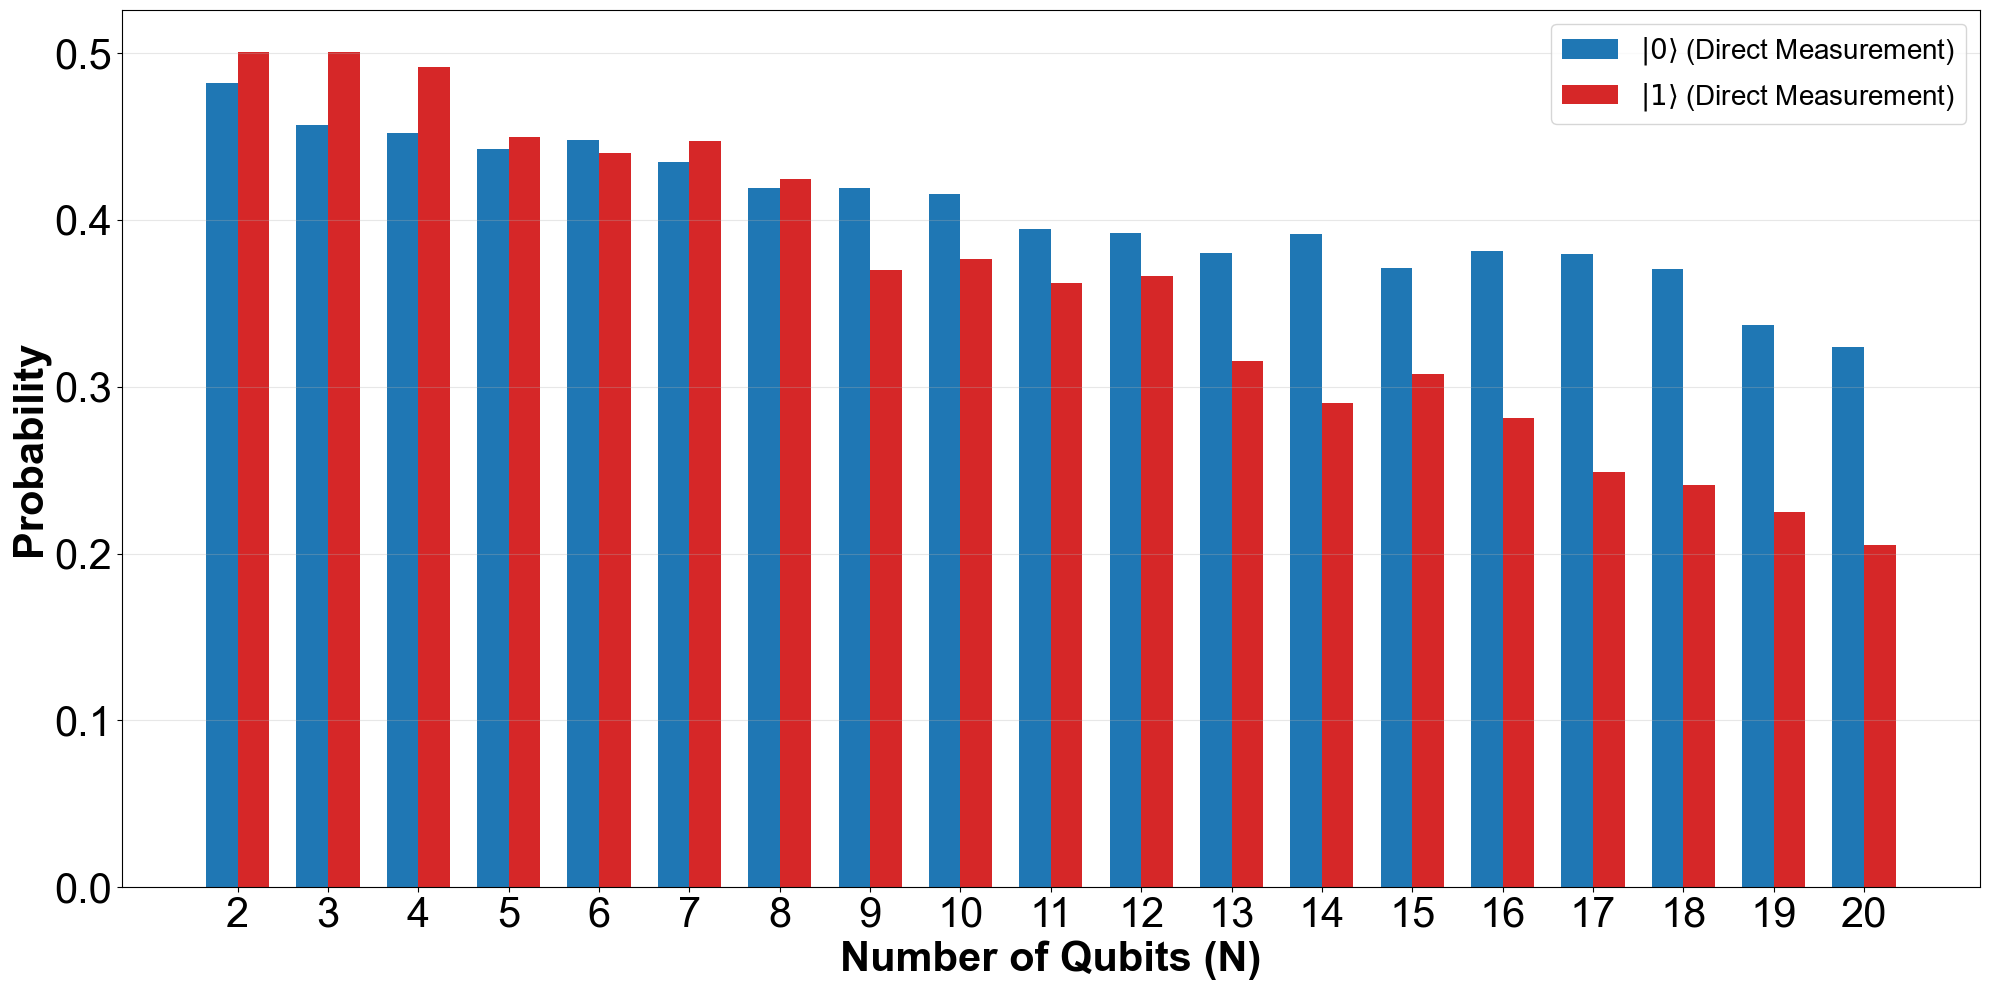

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 数据定义（替换为你的真实数据） ----------------------
# 比特数：2 ~ 20（共19个）
bit_counts = np.arange(2, 21)
x_labels = [f"{n}" for n in bit_counts]  # X轴标签：N 2, N 3, ..., N 20

# ========== 原始数据（基础部分） ==========


#后选择和不后选择比较
# p0_original = np.load("C:/Users/WASDH/Desktop/QClub/GHZ通信游戏项目/数据处理/2026-03-09/附录实验/读取/Line_No_select_prob0.npy").tolist()
# # 全1态原始测量概率（替换为你的真实列表，长度19）
# p1_original = np.load("C:/Users/WASDH/Desktop/QClub/GHZ通信游戏项目/数据处理/2026-03-09/附录实验/读取/Line_No_select_prob1.npy").tolist()

# ========== 排除热噪声后数据（提升后） ==========
# 全0态降噪后概率（需≥原始值，替换为你的真实列表，长度19）
p0_original = np.load("Tree_Post_select_prob0.npy").tolist()
# 全1态降噪后概率（需≥原始值，替换为你的真实列表，长度19）
p1_original = np.load("Tree_Post_select_prob1.npy").tolist()

# # 计算提升部分的高度（降噪后 - 原始，确保非负）
# p0_improve = np.maximum(0, np.array(p0_noise_free) - np.array(p0_original))
# p1_improve = np.maximum(0, np.array(p1_noise_free) - np.array(p1_original))

# ---------------------- 2. 绘图风格与布局配置 ----------------------
plt.rcParams['font.family'] = 'Arial'  # 学术字体
plt.rcParams['axes.unicode_minus'] = False       # 解决负号显示问题

fig, ax = plt.subplots(figsize=(20, 10))  # 画布尺寸匹配参考图
width = 0.35  # 柱状图宽度
x = np.arange(len(bit_counts))  # X轴位置索引

# 配色定义（原有深色 + 同色系淡色）
color_0_original = '#1f77b4'    # 全0原始：深蓝（匹配参考图）
color_1_original = '#d62728'    # 全1原始：深红（匹配参考图）

# ---------------------- 3. 绘制堆叠柱状图（基础+提升） ----------------------
# ===== 全0态：先画原始深色柱，再堆叠淡色提升柱 =====
# 原始基础柱
rects0_original = ax.bar(
    x - width/2, p0_original, width,
    label=r'$|0\rangle$ (Direct Measurement)',
    color=color_0_original
)
# # 淡色提升柱（堆叠在原始柱上方）
# rects0_improve = ax.bar(
#     x - width/2, p0_improve, width,
#     bottom=p0_original,  # 从原始柱顶部开始堆叠
#     label=r'$|0\rangle$ (Thermal-noise-removal Improvement)',
#     color=color_0_improve,
#     alpha=0.8  # 轻微透明，增强层次感
# )

# ===== 全1态：先画原始深色柱，再堆叠淡色提升柱 =====
# 原始基础柱
rects1_original = ax.bar(
    x + width/2, p1_original, width,
    label=r'$|1\rangle$ (Direct Measurement)',
    color=color_1_original
)
# # 淡色提升柱（堆叠在原始柱上方）
# rects1_improve = ax.bar(
#     x + width/2, p1_improve, width,
#     bottom=p1_original,  # 从原始柱顶部开始堆叠
#     label=r'$|1\rangle$ (Thermal-noise-removal Improvement)',
#     color=color_1_improve,
#     alpha=0.8  # 轻微透明，增强层次感
# )

# ---------------------- 4. 图表标注与美化 ----------------------
# 标题（补充降噪说明，贴合新数据）
# ax.set_title(
#     'Probability of measuring all 0s and all 1s in a GHZ state (with Noise-Free Optimization)',
#     fontsize=14, pad=15
# )
# 坐标轴标签
ax.set_ylabel('Probability', fontsize=30, fontweight='bold')
ax.set_xlabel("Number of Qubits (N)", fontsize=30, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=30)
# Y轴范围（适配提升后的数据，略高于最大值）
ax.tick_params(axis='y', labelsize=30)
# max_prob = max(np.max(p0_noise_free), np.max(p1_noise_free))
# ax.set_ylim(0, max_prob + 0.1)  # 顶部留空，更美观
# 浅灰色网格（仅Y轴，匹配参考图风格）
ax.grid(True, axis='y', linestyle='-', alpha=0.3)
# 图例（调整位置，避免遮挡）
ax.legend(fontsize=20, loc='upper right')

# ---------------------- 5. 显示/保存 ----------------------
plt.tight_layout()  # 自动调整布局，避免标签截断
# plt.savefig("ghz_all0_all1_prob_Noise_removal.svg", dpi=600, bbox_inches='tight')  # 保存高清图
plt.show()


# 2.b

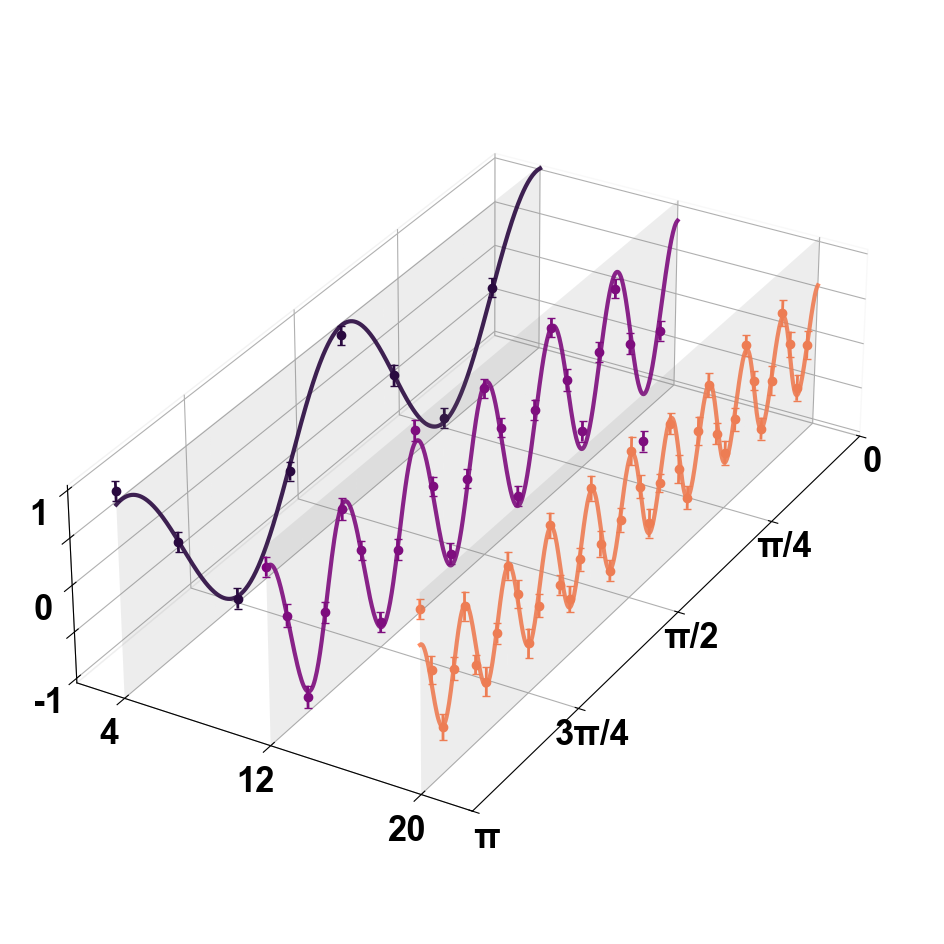

In [2]:
# ===================== 3D 交互式绘图：可旋转 + 可拖动 + 灰色背景 =====================
# 🔥 关键：切换成交互式后端
# %matplotlib qt
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ===================== 1. 完全使用你 2D 的所有函数 =====================
def process_2d_coherence_data(two_d_list):
    coherent_mean = []
    coherent_std = []
    for sub_list in two_d_list:
        sub_arr = np.array(sub_list)
        mean_val = np.mean(sub_arr)
        std_val = np.std(sub_arr, ddof=1)
        coherent_mean.append(mean_val)
        coherent_std.append(std_val)
    return np.array(coherent_mean), np.array(coherent_std)

def cos_ghz(theta, A, n, phi, B):
    return A * np.cos(n * theta + phi) + B

# ===================== 2. 加载 + 拟合逻辑（完全照搬你 2D） =====================
def load_data_N(N):
    f = f"20260309_10_coherent_result_{N}q_erro_bar.npy"
    result_list = np.load(f)
    
    # 【完全和你2D一样】生成 theta
    step = len(result_list)
    theta_list = np.arange(0, np.pi, np.pi / step)[:len(result_list)]
    
    # 【完全和你2D一样】处理数据
    coherent_mean, coherent_std = process_2d_coherence_data(result_list)
    
    # 【完全和你2D一样】拟合 + 边界
    initial_guess = [0.5, N, 0.0, 0.0]
    bounds = ((0.0, 0.1, -np.pi, -0.5), (1.0, N+2, np.pi, 0.5))
    fit_params, _ = curve_fit(cos_ghz, theta_list, coherent_mean, p0=initial_guess, bounds=bounds)
    
    # 【完全和你2D一样】平滑拟合线
    theta_dense = np.linspace(0, np.pi, 500)
    y_fit = cos_ghz(theta_dense, *fit_params)
    
    return theta_list, coherent_mean, coherent_std, theta_dense, y_fit

# ===================== 3. 只画你要的 3 条线 =====================
N_list = [4, 12, 20]
data = {N: load_data_N(N) for N in N_list}

# ===================== 4. 3D 绘图 =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(111, projection='3d')

# 视角（你要的角度）
ax.view_init(elev=30, azim=30)
ax.set_box_aspect((5.5, 3, 1.5))

# 颜色
colors = {4: '#2A0A40', 12: '#800080', 20: '#FF7F50'}
y_layers = {4: 0, 12: 3, 20: 6}

# ===================== 核心：灰色半透明背景面板 =====================
theta_dense = np.linspace(0, np.pi, 500)
X_grid, _ = np.meshgrid(theta_dense, [0, 1])

for N in N_list:
    theta_list, coherent_mean, coherent_std, _, y_fit = data[N]
    y = y_layers[N]
    
    # 灰色背景
    Y_grid = np.full_like(X_grid, y)
    Z_grid = np.meshgrid(theta_dense, [-1.05, 1.05])[1]
    
    ax.plot_surface(
        X_grid, Y_grid, Z_grid,
        color='gray', alpha=0.12, zorder=0,
        rstride=100, cstride=100, edgecolor='none'
    )
    
    # 拟合曲线
    ax.plot(
        theta_dense, 
        np.full_like(theta_dense, y), 
        y_fit,
        color=colors[N], linewidth=3, alpha=0.9, zorder=4
    )
    
    # 数据点
    ax.errorbar(
        theta_list, 
        np.full_like(theta_list, y), 
        coherent_mean,
        zerr=coherent_std,
        fmt='o', color=colors[N], 
        markersize=6, capsize=3, elinewidth=2, zorder=5
    )

# ===================== 坐标轴（完全保留你的设置） =====================
ax.set_xlim(np.pi, 0)
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi][::-1])
ax.set_xticklabels(['0', 'π/4', 'π/2', '3π/4', 'π'], fontsize=25, weight='bold')

ax.set_ylim(-1, 7)
ax.set_yticks([0, 3, 6])
ax.set_yticklabels(['4', '12', '20'], fontsize=25, weight='bold')

ax.set_zlim(-1.05, 1.05)
ax.set_zticks([-1,-0.5, 0, 0.5, 1])
ax.set_zticklabels(['-1', '', '0', '', '1'], fontsize=25, weight='bold')

# 样式
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(alpha=0.2)

plt.tight_layout()
# plt.savefig("3Dconherence_4.9.svg", dpi=600, bbox_inches='tight')
# 🔥 打开交互式独立窗口
plt.show()

# 2.c

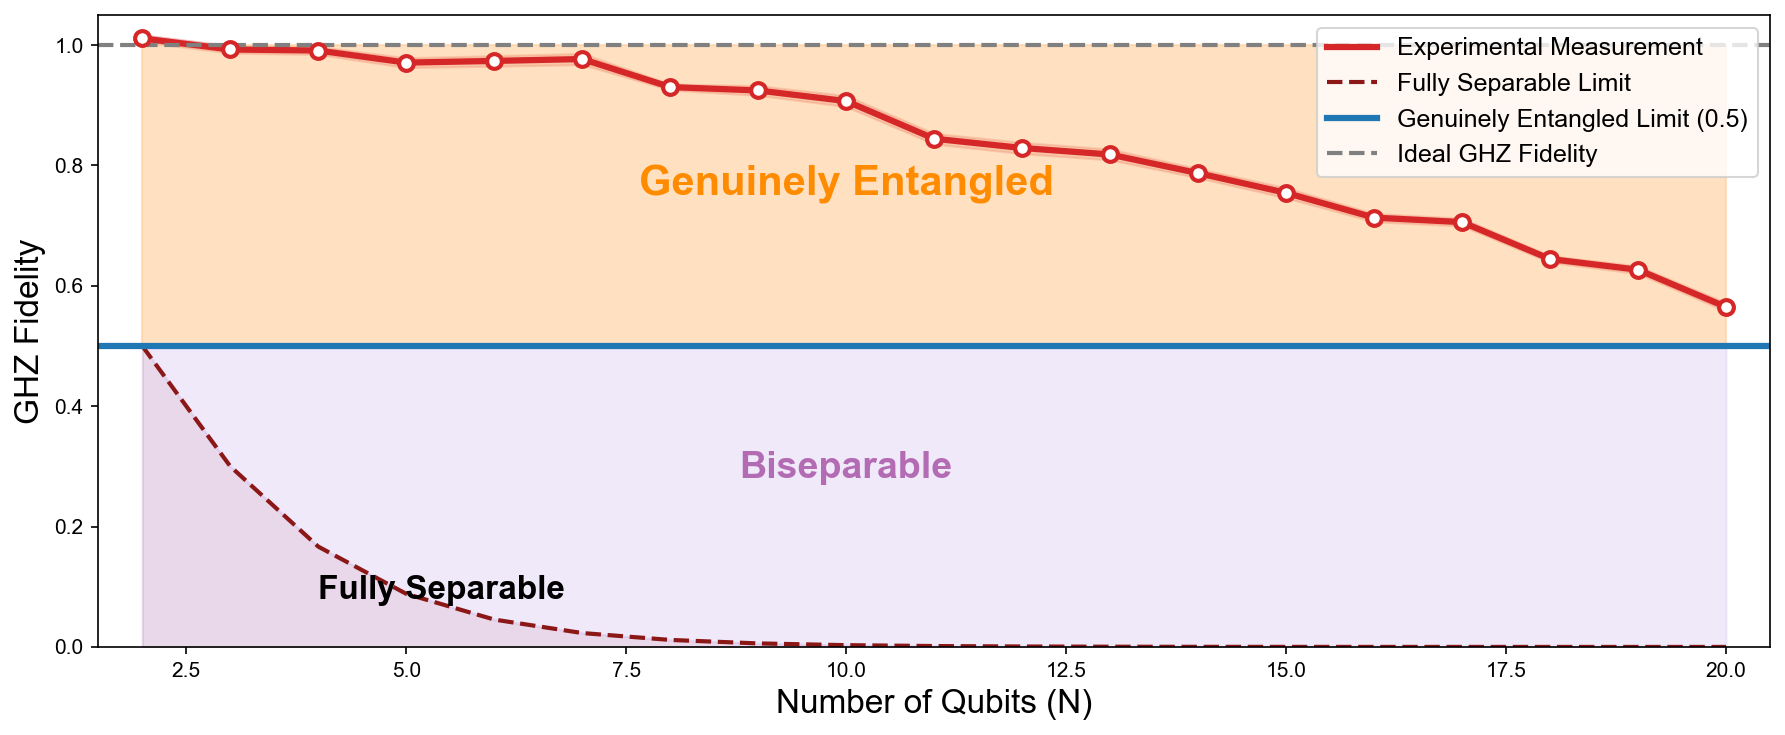

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 你只需要填这里！！！
# ======================
x_axis = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]  # 比特数 N

# 你的实验数据：每个 N 对应一组多次测量结果
# 格式：[[N=2的所有结果], [N=3的所有结果], [N=4的所有结果]...]
experimental_data = np.load("20260309_10_GHZ_fidelity_data_erro_bar.npy").tolist()


# 自动计算均值和误差（标准差）
means = []
errors = []
for data in experimental_data:
    means.append(np.mean(data))
    errors.append(np.std(data))

x = np.array(x_axis)
y = np.array(means)
err = np.array(errors)

# ======================
# 绘图（和你截图完全一样）
# ======================
plt.figure(figsize=(12, 5), dpi=150)
ax = plt.gca()

# 1. 实验曲线 + 误差带
ax.plot(x, y, color='#d62728', linewidth=3, linestyle='-', label='Experimental Measurement')
ax.fill_between(x, y-err, y+err, color='#d62728', alpha=0.3)
ax.scatter(x, y, color='white', edgecolor='#d62728', s=50, linewidth=2, zorder=5)

# 2. 完全可分极限 1/2^(N-1)
sep_limit = 3 / (2 * (2 ** (x - 1)+1))
ax.plot(x, sep_limit, color='#8c1717', linestyle='--', linewidth=2, label='Fully Separable Limit')

# 3. 真多体纠缠线 0.5
ax.axhline(0.5, color='#1f77b4', linewidth=3, linestyle='-', label='Genuinely Entangled Limit (0.5)')

# 4. 理想线 1.0
ax.axhline(1.0, color='gray', linestyle='--', linewidth=2, label='Ideal GHZ Fidelity')

# 5. 三色区域（和你图完全一致）
ax.fill_between(x, 0, sep_limit, color="#c79fcc", alpha=0.4)
ax.fill_between(x, sep_limit, 0.5, color="#e0d4f7", alpha=0.5)
ax.fill_between(x, 0.5, 1.0, color="#ffcc99", alpha=0.6)

# 6. 文字标注
ax.text(10, 0.75, "Genuinely Entangled", fontsize=20, color="#ff8c00", fontweight='bold', ha='center')
ax.text(10, 0.28, "Biseparable", fontsize=18, color="#b36bb3", fontweight='bold', ha='center')
ax.text(4, 0.08, "Fully Separable", fontsize=16, fontweight='bold')

# 坐标轴设置
ax.set_xlabel("Number of Qubits (N)", fontsize=16)
ax.set_ylabel("GHZ Fidelity", fontsize=16)
ax.set_ylim(0, 1.05)
ax.set_xlim(min(x)-0.5, max(x)+0.5)
ax.legend(fontsize=12, loc='upper right')


plt.tight_layout()
plt.show()

# 2.d


✅ 20-bit GHZ Fidelity: 0.629771

🎨 全局最大高度 = 0.426477


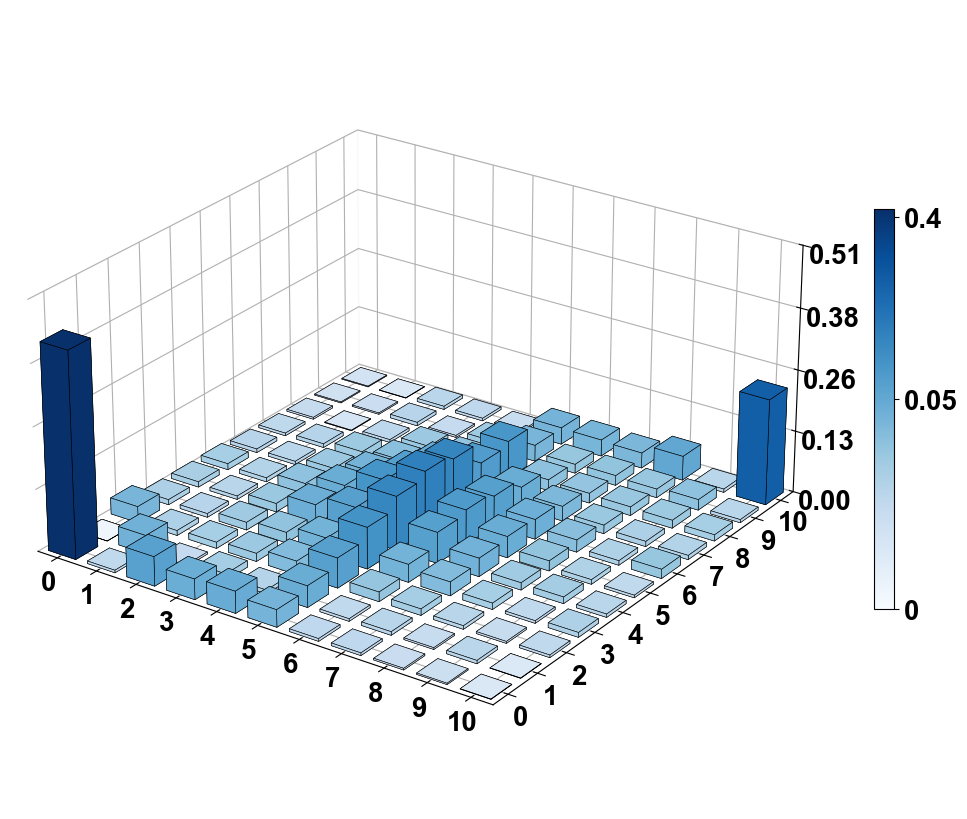

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, art3d
from matplotlib.colors import PowerNorm
import warnings
warnings.filterwarnings('ignore')

# ===================== 核心参数 =====================
n_bits = 20
prob_list = np.load(f"20260309_10_real_state_data_{n_bits}q.npy").tolist()

# 可视化参数
figure_size = (16, 10)
bar_alpha = 1.0
cmap_3d = plt.cm.Blues
dx = dy = 0.70
view_azim = -55
view_elev = 25
label_fontsize = 20
label_fontweight = 'bold'

# ===================== 全局字体 =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# ===================== 数据处理 =====================
def process_prob_data(prob_list, n_bits):
    total_strings = 2**n_bits
    if len(prob_list) != total_strings:
        raise ValueError(f"Expected {total_strings}, got {len(prob_list)}")
    
    prob_array = np.array(prob_list, dtype=np.float64)
    neg_mask = prob_array < 0
    abs_neg_sum = np.abs(np.sum(prob_array[neg_mask]))
    prob_array[neg_mask] = 0
    
    if abs_neg_sum > 1e-10:
        prob_array += abs_neg_sum / total_strings
    return prob_array.tolist()

prob_list = process_prob_data(prob_list, n_bits)

# ===================== 汉明重量计算 =====================
def get_hamming_weight_n_bit(idx, n_bits):
    half_bits = n_bits // 2
    bin_str = bin(idx)[2:].zfill(n_bits)
    return bin_str[:half_bits].count('1'), bin_str[half_bits:].count('1')

half_bits = n_bits // 2
max_hw = half_bits
prob_matrix = np.zeros((max_hw + 1, max_hw + 1))

for idx in range(2**n_bits):
    hw1, hw2 = get_hamming_weight_n_bit(idx, n_bits)
    prob_matrix[hw1, hw2] += prob_list[idx]

# ===================== 保真度计算 =====================
def calculate_ghz_fidelity(prob_list, n_bits):
    ideal_amp = np.zeros(2**n_bits, dtype=np.complex128)
    ideal_amp[0] = ideal_amp[-1] = 1 / np.sqrt(2)
    return np.abs(np.sum(ideal_amp.conj() * np.sqrt(prob_list))) ** 2

fidelity = calculate_ghz_fidelity(prob_list, n_bits)
print(f"\n✅ {n_bits}-bit GHZ Fidelity: {fidelity:.6f}")

# ===================== 🔥 纯色柱子 + 黑色轮廓线 =====================
def add_solid_color_bar_with_edge(ax, x, y, z_h, dx, dy, alpha, sm_global):
    if z_h < 1e-10:
        return
    
    x0, x1 = x - dx/2, x + dx/2
    y0, y1 = y - dy/2, y + dy/2
    z0, z1 = 0, z_h
    
    color = sm_global.to_rgba(z_h)
    
    faces = [
        [(x0,y0,z0), (x1,y0,z0), (x1,y1,z0), (x0,y1,z0)],
        [(x0,y0,z1), (x1,y0,z1), (x1,y1,z1), (x0,y1,z1)],
        [(x0,y0,z0), (x1,y0,z0), (x1,y0,z1), (x0,y0,z1)],
        [(x0,y1,z0), (x1,y1,z0), (x1,y1,z1), (x0,y1,z1)],
        [(x0,y0,z0), (x0,y1,z0), (x0,y1,z1), (x0,y0,z1)],
        [(x1,y0,z0), (x1,y1,z0), (x1,y1,z1), (x1,y0,z1)],
    ]
    
    poly = art3d.Poly3DCollection(
        faces, facecolors=color,
        edgecolor='black', linewidth=0.4,
        alpha=alpha, antialiased=True
    )
    ax.add_collection3d(poly)

# ===================== 绘制主图 =====================
fig = plt.figure(figsize=figure_size)
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect((2, 2, 1))
fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

global_z_max = np.max(prob_matrix)
print(f"\n🎨 全局最大高度 = {global_z_max:.6f}")

# ===================== 3D 柱子颜色映射（非均匀） =====================
sm_global = plt.cm.ScalarMappable(
    norm=PowerNorm(gamma=0.3, vmin=0, vmax=global_z_max),
    cmap=cmap_3d
)
sm_global.set_array([])

# 绘制所有3D柱子
x_coords = np.arange(max_hw + 1)
y_coords = np.arange(max_hw + 1)
for i, x in enumerate(x_coords):
    for j, y in enumerate(y_coords):
        z_h = prob_matrix[i, j]
        add_solid_color_bar_with_edge(ax, x, y, z_h, dx, dy, bar_alpha, sm_global)

# ===================== 坐标轴 =====================
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='-', alpha=0.05)

ax.set_xlim(-0.5, max_hw + 0.5)
ax.set_ylim(-0.5, max_hw + 0.5)
ax.set_zlim(0, global_z_max * 1.2)

ax.set_xticks(x_coords)
ax.set_yticks(x_coords)
ax.set_zticks(np.linspace(0, global_z_max * 1.2, 5))

ax.set_yticklabels([str(i) for i in range(max_hw+1)], fontsize=20, fontweight='bold')
ax.set_xticklabels([str(i) for i in range(max_hw+1)], fontsize=20, fontweight='bold')
ax.set_zticklabels([f"{v:.2f}" for v in np.linspace(0, global_z_max*1.2,5)], fontsize=20, fontweight='bold')

ax.tick_params(axis='y', pad=0, length=20)
ax.tick_params(axis='x', pad=0, length=20)
ax.tick_params(axis='z', pad=5, length=20)

# ===================== 颜色条（只显示0,0.05,0.4） =====================
cbar = fig.colorbar(sm_global, ax=ax, shrink=0.5, pad=0.05)
cbar.set_ticks([0, 0.05, 0.4])
cbar.set_ticklabels(['0', '0.05', '0.4'], fontsize=20, fontweight='bold')

# 视角
ax.view_init(azim=view_azim, elev=view_elev)
plt.tight_layout()
# plt.savefig("3D柱状图.svg", dpi=600)
plt.show()

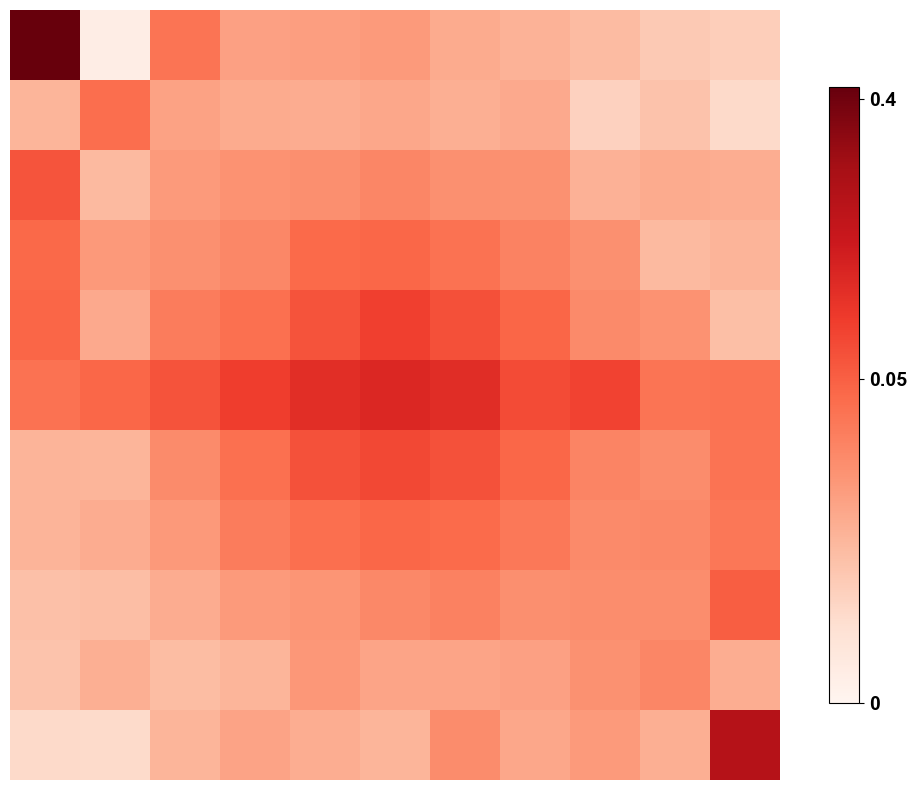

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import warnings
warnings.filterwarnings('ignore')

# ===================== 核心参数 =====================
n_bits = 20
prob_list = np.load(f"20260309_10_real_state_data_{n_bits}q.npy").tolist()

# 可视化参数
figure_size = (10, 8)
cmap_heatmap = plt.cm.Reds  # 红色热力图
gamma = 0.3                # 非线性映射

# ===================== 全局字体 =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# ===================== 数据处理 =====================
def process_prob_data(prob_list, n_bits):
    total_strings = 2**n_bits
    if len(prob_list) != total_strings:
        raise ValueError(f"Expected {total_strings}, got {len(prob_list)}")
    
    prob_array = np.array(prob_list, dtype=np.float64)
    neg_mask = prob_array < 0
    abs_neg_sum = np.abs(np.sum(prob_array[neg_mask]))
    prob_array[neg_mask] = 0
    
    if abs_neg_sum > 1e-10:
        prob_array += abs_neg_sum / total_strings
    return prob_array.tolist()

prob_list = process_prob_data(prob_list, n_bits)

# ===================== 汉明重量计算 =====================
def get_hamming_weight_n_bit(idx, n_bits):
    half_bits = n_bits // 2
    bin_str = bin(idx)[2:].zfill(n_bits)
    return bin_str[:half_bits].count('1'), bin_str[half_bits:].count('1')

half_bits = n_bits // 2
max_hw = half_bits
prob_matrix = np.zeros((max_hw + 1, max_hw + 1))

for idx in range(2**n_bits):
    hw1, hw2 = get_hamming_weight_n_bit(idx, n_bits)
    prob_matrix[hw1, hw2] += prob_list[idx]

# ===================== 绘制 2D 红色热力图 =====================
fig, ax = plt.subplots(figsize=figure_size)

# 非线性颜色映射
norm = PowerNorm(gamma=gamma, vmin=0, vmax=np.max(prob_matrix))

# 绘制热力图
im = ax.imshow(
    prob_matrix,
    cmap=cmap_heatmap,
    norm=norm,
    aspect='equal'
)

# ===================== 完全隐藏坐标轴、刻度 =====================
ax.set_xticks([])
ax.set_yticks([])
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

# ===================== 颜色条 =====================
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_ticks([0, 0.05, 0.4])
cbar.set_ticklabels(['0', '0.05', '0.4'], fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig("2D热力图.svg", dpi=600)
plt.show()

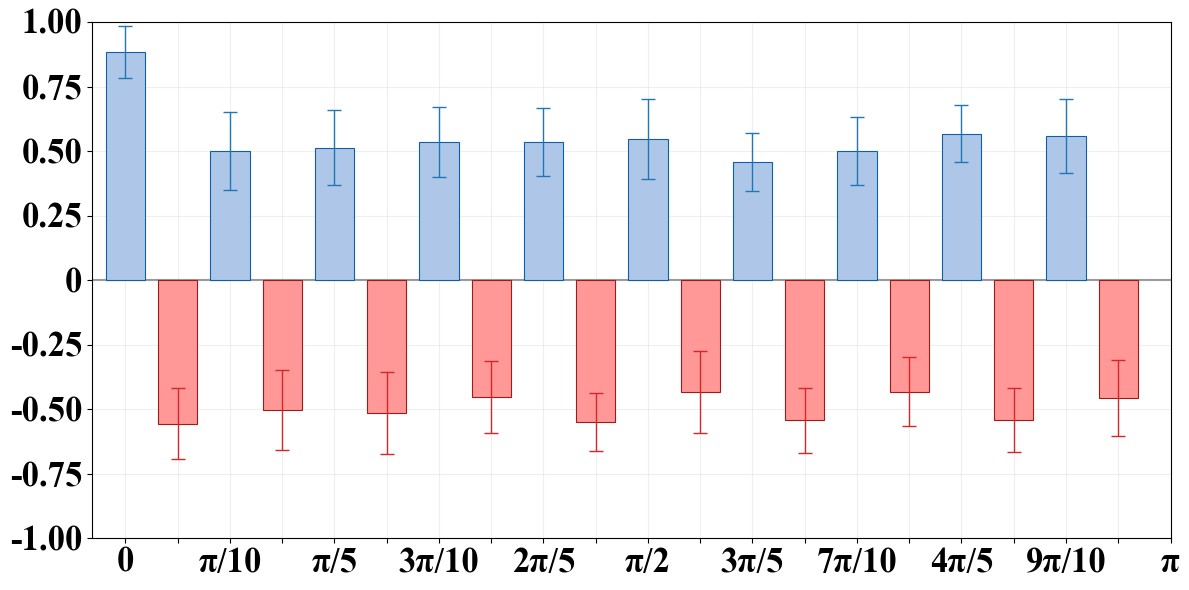

===== GHZ 相干度分析结果（纯色分色版） =====
Y轴范围：[-1.00, 1.00]（强制最大值为1）
偶数序号数量 = 20
正半轴：纯色蓝（#1f77b4），误差棒同色
负半轴：纯色红（#d62728），误差棒同色
0值柱子：浅灰色，误差棒黑色
X轴标签间隔：每2个刻度显示1个标签


In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# ===================== 全局变量（按需调整） =====================
N_test = 20  # 比特数
step = 50   # 相位扫描点数
shots = 5000

# 加载数据（保留你的原始路径）
f = f"20260309_10_coherent_result_{N_test}q_erro_bar.npy"
result_list = np.load(f)

elsephaselist = np.linspace(0, np.pi, len(result_list))

# ===================== 核心配置 =====================
n_qubits = N_test
step = len(result_list)
theta_list = np.arange(0, np.pi, np.pi / step)[:len(result_list)]

# ===================== 处理二维列表（保留） =====================
def process_2d_coherence_data(two_d_list):
    coherent_mean = []
    coherent_std = []
    for sub_list in two_d_list:
        sub_arr = np.array(sub_list)
        mean_val = np.mean(sub_arr)
        std_val = np.std(sub_arr, ddof=1)
        coherent_mean.append(mean_val)
        coherent_std.append(std_val)
    return np.array(coherent_mean), np.array(coherent_std)

coherent_mean, coherent_std = process_2d_coherence_data(result_list)

# ===================== 核心：选偶数序号的点作为峰谷值 =====================
even_idx = np.arange(0, len(theta_list), 2)
extrema_theta = theta_list[even_idx]
extrema_mean = coherent_mean[even_idx]
extrema_std = coherent_std[even_idx]

# ===================== 核心：生成坐标轴刻度（0、π/20、π/10…π） =====================
tick_step = np.pi / 20
tick_positions = np.arange(0, np.pi + tick_step, tick_step)

# 新增：间隔显示参数（每N个刻度显示1个标签，可自由调整）
tick_display_interval = 2  # 每2个刻度显示1个（比如0、π/5、2π/5…π）
tick_labels = []

for i, pos in enumerate(tick_positions):
    # 1. 强制保留0和π的标签
    if i == 0:
        tick_labels.append('0')
    elif i == len(tick_positions)-1:  # 最后一个是π
        tick_labels.append('π')
    # 2. 按间隔显示其余标签（索引是interval倍数才显示）
    elif i % tick_display_interval == 0:
        numerator = i
        denominator = 20
        gcd_val = np.gcd(numerator, denominator)
        num = numerator // gcd_val
        den = denominator // gcd_val
        if num == 1:
            tick_labels.append(f'π/{den}')
        else:
            tick_labels.append(f'{num}π/{den}')
    # 3. 非间隔位置：隐藏标签（设为空字符串）
    else:
        tick_labels.append('')

# ===================== 绘图（核心修改：纯色填充+分色误差棒） =====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 6))

# ---------------------- 1. Y轴配置（最大1，保留0基准线） ----------------------
y_min = min(np.min(extrema_mean - extrema_std), -1)
y_max = 1.0  # 强制最大值为1
ax.set_ylim(y_min, y_max)

# 增加Y轴刻度（每0.25一个）
y_ticks = np.arange(np.floor(y_min*10)/10, y_max + 0.1, 0.25)
y_tick_labels = [f'{tick:.2f}' if not np.isclose(tick, 0) else '0' for tick in y_ticks]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_tick_labels, fontsize=25, fontweight='bold')

# 保留y=0基准线（醒目实线）
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)

# ---------------------- 2. 定义正负纯色（核心修改：取消渐变） ----------------------
# 正半轴：纯色蓝（学术常用：#1f77b4）
color_pos = '#1f77b4'
# 负半轴：纯色红（学术常用：#d62728）
color_neg = '#d62728'
# 0值柱子：浅灰色
color_zero = '#F0F0F0'

bar_width = (np.pi / step) * 1.5

# ---------------------- 3. 逐根绘制纯色柱子+分色误差棒（核心重构） ----------------------
for i, (theta, val, std) in enumerate(zip(extrema_theta, extrema_mean, extrema_std)):
    # 柱子位置和尺寸
    x = theta
    height = val
    width = bar_width
    
    if height > 0:
        # 正值柱子：纯色蓝 + 同色系深一点的边框（增强轮廓）
        rect = plt.Rectangle((x - width/2, 0), width, height, 
                             facecolor='#aec7e8',  # 纯色填充
                             edgecolor='#0f5ea8',  # 深蓝边框
                             linewidth=0.8, zorder=2)
        ax.add_patch(rect)
        # 正值误差棒：蓝色
        err_color = color_pos
    
    elif height < 0:
        # 负值柱子：纯色红 + 同色系深一点的边框（增强轮廓）
        rect = plt.Rectangle((x - width/2, height), width, -height, 
                             facecolor='#ff9896',  # 纯色填充
                             edgecolor='#a01a1a',  # 深红边框
                             linewidth=0.8, zorder=2)
        ax.add_patch(rect)
        # 负值误差棒：红色
        err_color = color_neg
    
    else:
        # 0值柱子：浅灰色纯色
        rect = plt.Rectangle((x - width/2, -0.01), width, 0.02, 
                             facecolor=color_zero,
                             edgecolor='gray', 
                             linewidth=0.8, zorder=2)
        ax.add_patch(rect)
        # 0值误差棒：黑色
        err_color = 'black'
    
    # 绘制误差棒（分色，置顶显示）
    ax.errorbar(x, val, yerr=std, ecolor=err_color, elinewidth=1, capsize=5, 
                capthick=1, zorder=3, fmt='none')

# ---------------------- 4. X轴配置（间隔显示标签） ----------------------
ax.set_xlim(-0.1, np.pi)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=25, rotation=0, fontweight='bold')
ax.grid(alpha=0.2, zorder=0)

plt.tight_layout()
# 保存图片（按需取消注释）
plt.show()

# ===================== 输出结果 =====================
print("===== GHZ 相干度分析结果（纯色分色版） =====")
print(f"Y轴范围：[{y_min:.2f}, {y_max:.2f}]（强制最大值为1）")
print(f"偶数序号数量 = {len(extrema_theta)}")
print(f"正半轴：纯色蓝（#1f77b4），误差棒同色")
print(f"负半轴：纯色红（#d62728），误差棒同色")
print(f"0值柱子：浅灰色，误差棒黑色")
print(f"X轴标签间隔：每{tick_display_interval}个刻度显示1个标签")